# BSARD Corpus — Exploratory Analysis

**Two sections:**
1. **Dataset statistics** — distributions, breakdowns, and coverage across the full 40 K-article corpus
2. **Article deep-dive** — inspect any article by BSARD ID, article number, or law code; see all metadata, text, citations, and linked questions


In [1]:
import json
import re
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT       = Path("../output")
DB_PATH    = ROOT / "bsard_corpus.db"
STATS_PATH = ROOT / "corpus_stats.json"

# ── Connect ───────────────────────────────────────────────────────────────────
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

with open(STATS_PATH, encoding="utf-8") as f:
    STATS = json.load(f)

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print(f"Connected to: {DB_PATH}")
print(f"Articles : {conn.execute('SELECT COUNT(*) FROM articles').fetchone()[0]:,}")
print(f"Questions: {conn.execute('SELECT COUNT(*) FROM questions').fetchone()[0]:,}")
print(f"Cit.edges: {conn.execute('SELECT COUNT(*) FROM citation_graph').fetchone()[0]:,}")

Connected to: ..\output\bsard_corpus.db
Articles : 40,231
Questions: 1,108
Cit.edges: 27,712


---
## Part 1 — Dataset Statistics

### 1.1 Corpus Overview

In [2]:
ov = STATS["corpus_overview"]
overview_df = pd.DataFrame([
    ("Total articles",       ov["total_articles"]),
    ("BSARD articles",       ov["bsard_articles"]),
    ("Non-BSARD articles",   ov["non_bsard_articles"]),
    ("Unique BSARD IDs",     ov["unique_bsard_ids"]),
    ("Unique law codes",     ov["unique_law_codes"]),
    ("PDFs processed",       ov["unique_pdfs"]),
    ("Citation edges",       STATS["cross_references"]["total_citation_edges"]),
    ("Questions total",      STATS["questions"]["total"]),
    ("Questions (train)",    STATS["questions"]["train"]),
    ("Questions (test)",     STATS["questions"]["test"]),
], columns=["Metric", "Value"])
overview_df["Value"] = overview_df["Value"].apply(lambda x: f"{x:,}")
display(overview_df.set_index("Metric"))

,Value
Metric,
Total articles,"40,231"
BSARD articles,"33,741"
Non-BSARD articles,"6,490"
Unique BSARD IDs,"22,633"
Unique law codes,34
PDFs processed,49
Citation edges,"27,712"
Questions total,"1,108"
Questions (train),886


### 1.2 Articles per Law Code

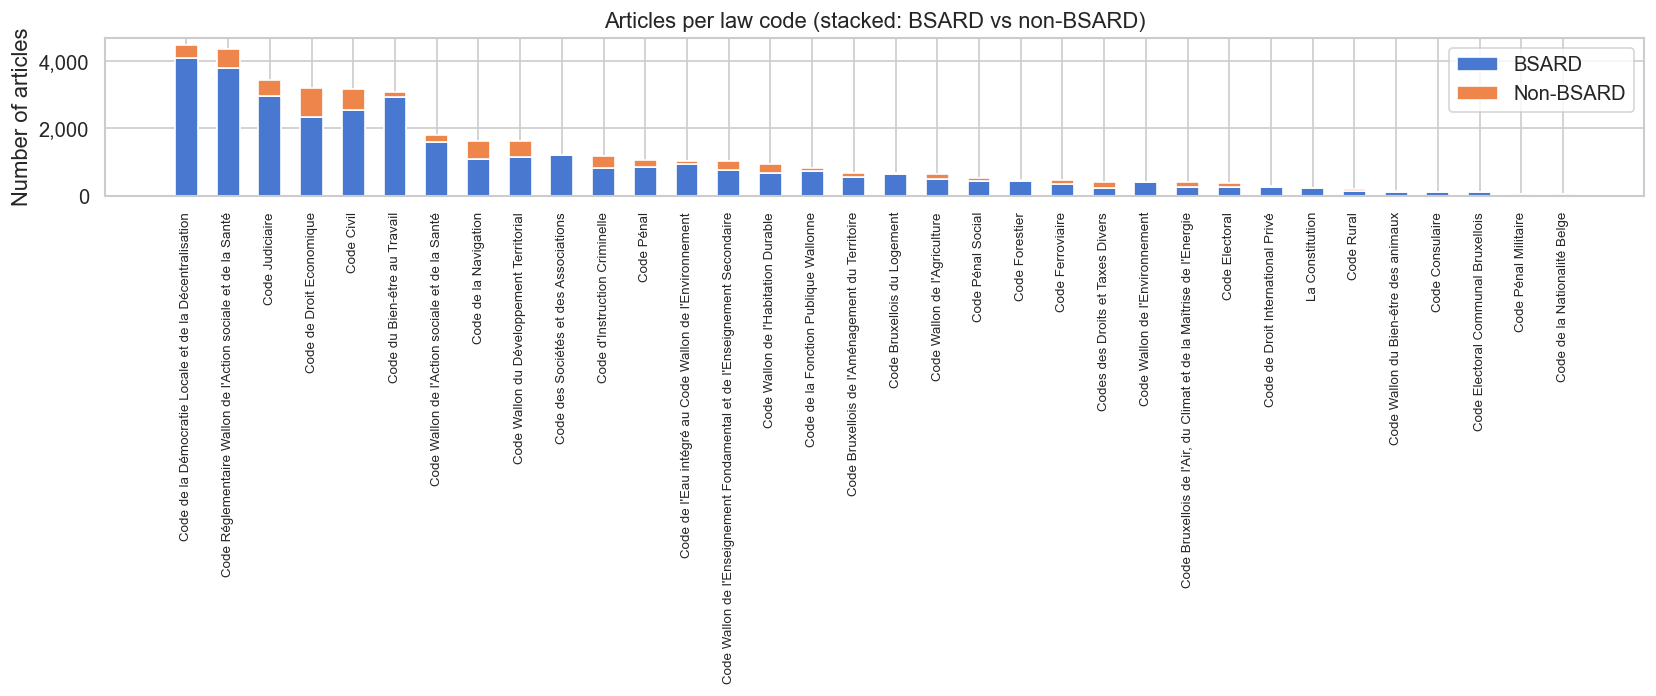

,total,bsard,non_bsard
law_code,,,
Code de la Démocratie Locale et de la Décentralisation,"4,464","4,083",381
Code Réglementaire Wallon de l'Action sociale et de la Santé,"4,355","3,791",564
Code Judiciaire,"3,432","2,971",461
Code de Droit Economique,"3,188","2,345",843
Code Civil,"3,163","2,546",617
Code du Bien-être au Travail,"3,064","2,935",129
Code Wallon de l'Action sociale et de la Santé,"1,811","1,600",211
Code de la Navigation,"1,613","1,077",536
Code Wallon du Développement Territorial,"1,612","1,152",460


In [3]:
law_df = pd.read_sql("""
    SELECT law_code,
           COUNT(*) AS total,
           SUM(is_bsard_article) AS bsard,
           SUM(1 - is_bsard_article) AS non_bsard
    FROM articles
    GROUP BY law_code
    ORDER BY total DESC
""", conn)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(law_df))
w = 0.55
ax.bar(x, law_df["bsard"],     width=w, label="BSARD",     color="#4878d0")
ax.bar(x, law_df["non_bsard"], width=w, label="Non-BSARD", color="#ee854a",
       bottom=law_df["bsard"])
ax.set_xticks(x)
ax.set_xticklabels(law_df["law_code"], rotation=90, fontsize=8)
ax.set_ylabel("Number of articles")
ax.set_title("Articles per law code (stacked: BSARD vs non-BSARD)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

display(law_df.set_index("law_code").style.format("{:,}"))

### 1.3 Article Length Distribution

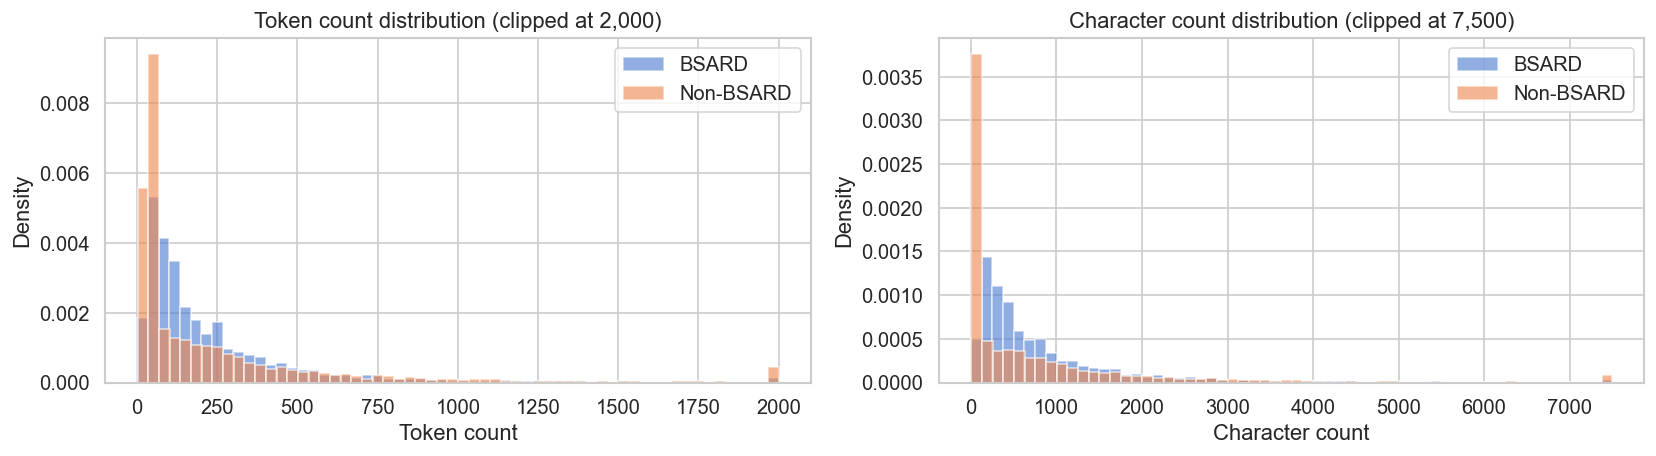

,Token count,Char count
p10,36,111
p25,63,231
p50,133,492
p75,289,1045
p90,550,1979
p95,798,2848
p99,1609,5746


In [4]:
len_df = pd.read_sql("""
    SELECT token_count, char_count, is_bsard_article
    FROM articles
    WHERE token_count IS NOT NULL
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label, clip in zip(
    axes,
    ["token_count", "char_count"],
    ["Token count", "Character count"],
    [2000, 7500],
):
    data = len_df[col].clip(upper=clip)
    ax.hist(data[len_df["is_bsard_article"] == 1], bins=60, alpha=0.6,
            label="BSARD",     color="#4878d0", density=True)
    ax.hist(data[len_df["is_bsard_article"] == 0], bins=60, alpha=0.6,
            label="Non-BSARD", color="#ee854a", density=True)
    ax.set_xlabel(label)
    ax.set_ylabel("Density")
    ax.set_title(f"{label} distribution (clipped at {clip:,})")
    ax.legend()

plt.tight_layout()
plt.show()

# Percentile table
pcts = [10, 25, 50, 75, 90, 95, 99]
pct_df = pd.DataFrame({
    "Token count": np.percentile(len_df["token_count"].dropna(), pcts).astype(int),
    "Char count":  np.percentile(len_df["char_count"].dropna(),  pcts).astype(int),
}, index=[f"p{p}" for p in pcts])
display(pct_df)

### 1.4 Text Source Breakdown

C:\Users\pasch\AppData\Local\Temp\ipykernel_12228\2760592609.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=src_len, x="article_text_source", y="token_count",


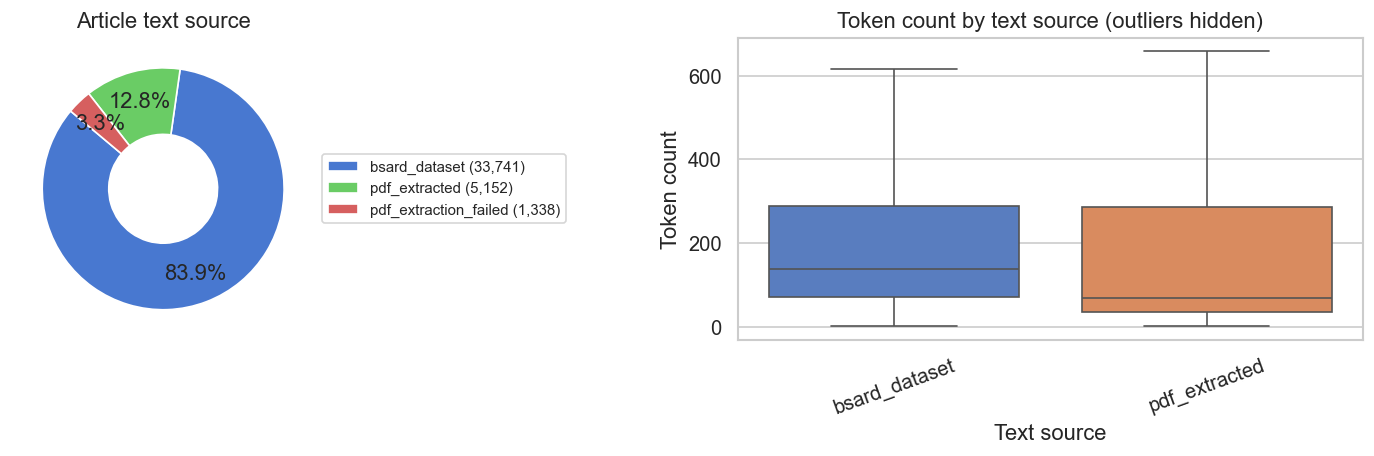

In [5]:
src = STATS["text_source"]
labels = list(src.keys())
values = list(src.values())
colors = ["#4878d0", "#6acc65", "#d65f5f", "#b47cc7", "#c4ad66"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

wedges, texts, autotexts = ax1.pie(
    values, labels=None, autopct="%1.1f%%",
    colors=colors[:len(labels)], startangle=140,
    pctdistance=0.75, wedgeprops=dict(width=0.55)
)
ax1.legend(wedges, [f"{l} ({v:,})" for l, v in zip(labels, values)],
           loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)
ax1.set_title("Article text source")

# Box plot of token count by source
src_len = pd.read_sql("""
    SELECT article_text_source, token_count
    FROM articles WHERE token_count IS NOT NULL
""", conn)
order = src_len.groupby("article_text_source")["token_count"].median().sort_values(ascending=False).index
sns.boxplot(data=src_len, x="article_text_source", y="token_count",
            order=order, ax=ax2, showfliers=False, palette="muted")
ax2.set_xlabel("Text source")
ax2.set_ylabel("Token count")
ax2.set_title("Token count by text source (outliers hidden)")
ax2.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### 1.5 Hierarchy Coverage

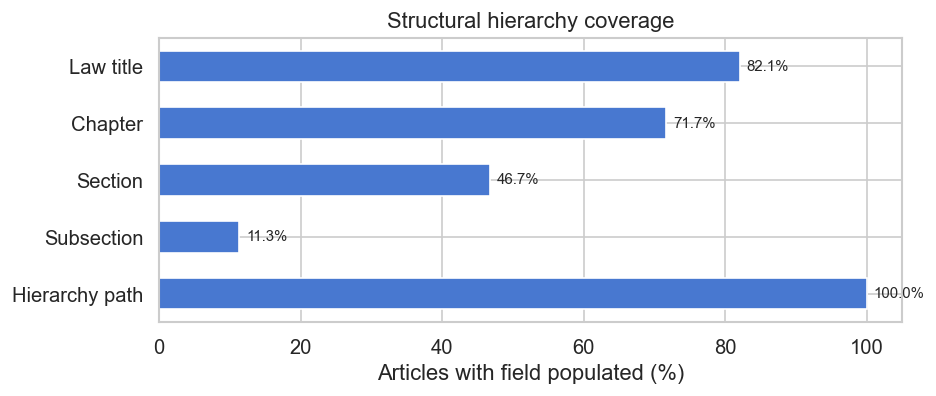

In [6]:
hc = STATS["hierarchy_coverage"]
hc_df = pd.DataFrame([
    ("Law title",      hc["has_law_title"]),
    ("Chapter",        hc["has_chapter"]),
    ("Section",        hc["has_section"]),
    ("Subsection",     hc["has_subsection"]),
    ("Hierarchy path", hc["has_hierarchy_path"]),
], columns=["Level", "Coverage (%)"])

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(hc_df["Level"][::-1], hc_df["Coverage (%)"][::-1],
               color="#4878d0", height=0.55)
ax.set_xlim(0, 105)
ax.set_xlabel("Articles with field populated (%)")
ax.set_title("Structural hierarchy coverage")
for bar, val in zip(bars, hc_df["Coverage (%)"][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### 1.6 Cross-Reference / Citation Network

Total citation edges : 27,712
Articles with refs   : 21,300 (52.9%)
Max in-degree        : 269 (Art.2, Code des Sociétés et des Associations)


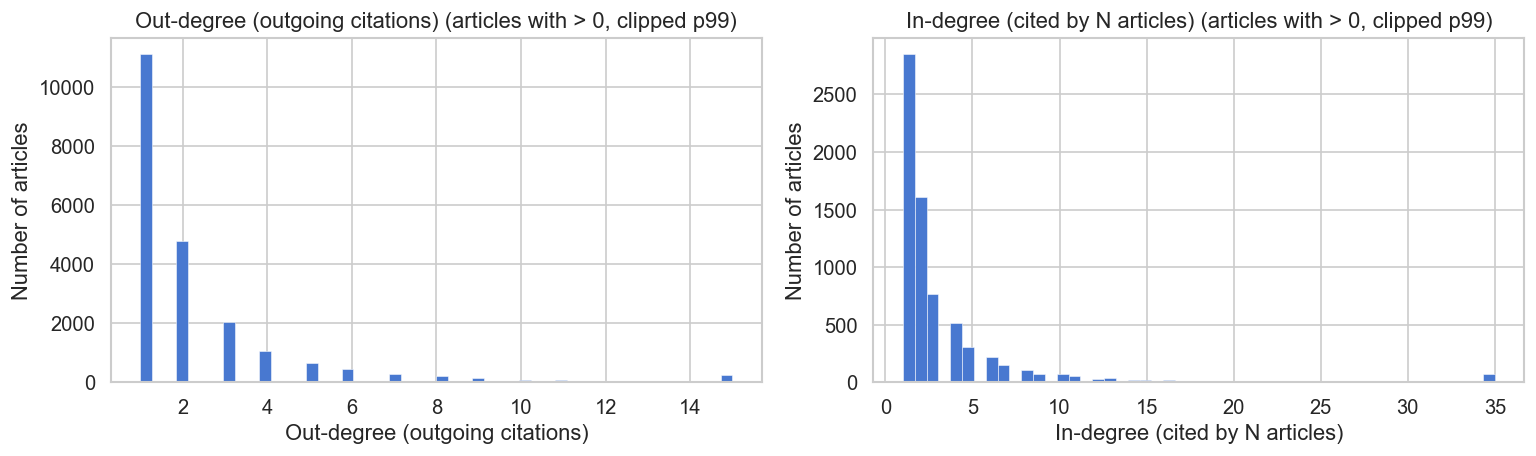

,article_id,bsard_id,law_code,article_number,n_cited_by,preview
0,37825,19791,Code des Sociétés et des Associations,2,269,Les dispositions du présent livre s'appliquent...
1,36737,17068,Code de la Démocratie Locale et de la Décentra...,L1124,203,§ 1er. Le directeur général est nommé par le c...
2,39074,21043,Code du Bien-être au Travail,I.4,177,§ 1er. Sans préjudice des obligations spécifiq...
3,37273,17698,Code de la Démocratie Locale et de la Décentra...,L3331,152,§ 1er. Le présent titre s'applique à toute sub...
4,13781,17347,Code de la Démocratie Locale et de la Décentra...,L1332-19,133,§ 1er. Une dotation complémentaire est allouée...
5,14279,18042,Code de la Démocratie Locale et de la Décentra...,L4145-5,131,Il est défendu au fonctionnaire qui reçoit une...
6,38391,20357,Code des Sociétés et des Associations,7,131,La société anonyme est une société dotée d'un ...
7,37974,19940,Code des Sociétés et des Associations,3,118,"§ 1er. Chaque année, l'organe d'administration..."
8,135,890,Code Civil,2,113,"On ne peut déroger, par des conventions partic..."
9,31562,22104,Code du Bien-être au Travail,VII.1-3,103,La notification visée aux articles VII.1-77 à ...


In [7]:
cr = STATS["cross_references"]
print(f"Total citation edges : {cr['total_citation_edges']:,}")
print(f"Articles with refs   : {cr['articles_with_references']:,} ({cr['pct_with_references']:.1f}%)")
print(f"Max in-degree        : {cr['max_in_degree']} "
      f"(Art.{cr['max_in_degree_article_no']}, {cr['max_in_degree_law_code']})")

# In-degree and out-degree distributions
deg_df = pd.read_sql("""
    SELECT n_outgoing_refs, n_cited_by, law_code
    FROM articles
""", conn)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in [
    (axes[0], "n_outgoing_refs", "Out-degree (outgoing citations)"),
    (axes[1], "n_cited_by",      "In-degree (cited by N articles)"),
]:
    data = deg_df[col][deg_df[col] > 0]
    ax.hist(data.clip(upper=data.quantile(0.99)), bins=50,
            color="#4878d0", edgecolor="white", linewidth=0.3)
    ax.set_xlabel(label)
    ax.set_ylabel("Number of articles")
    ax.set_title(f"{label} (articles with > 0, clipped p99)")

plt.tight_layout()
plt.show()

# Top 15 most-cited articles
top_cited = pd.read_sql("""
    SELECT article_id, bsard_id, law_code, article_number, n_cited_by,
           substr(article_text, 1, 120) AS preview
    FROM articles
    ORDER BY n_cited_by DESC
    LIMIT 15
""", conn)
display(top_cited)

### 1.7 Top 15 law codes by average outgoing citations

C:\Users\pasch\AppData\Local\Temp\ipykernel_12228\2052662617.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10, y="law_code", x="avg_outgoing", ax=ax, palette="Blues_r")


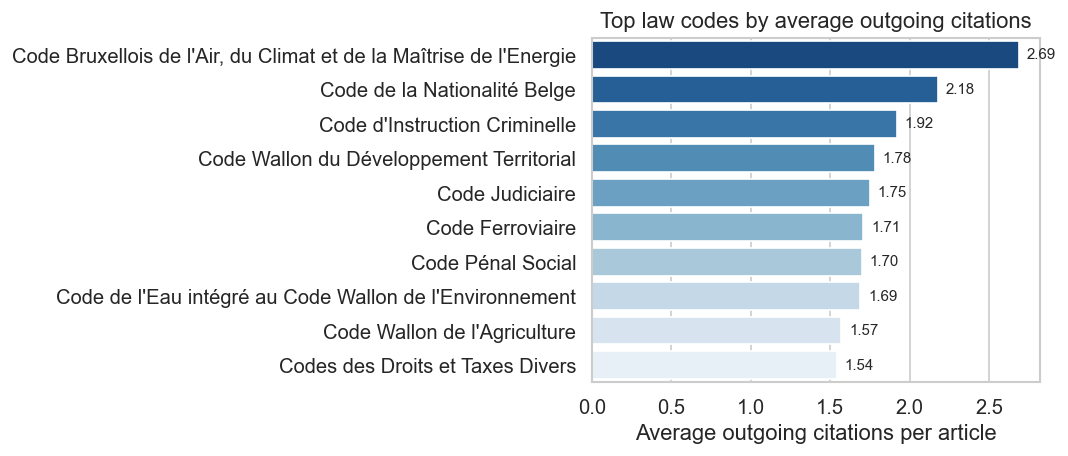

In [8]:
top10 = pd.DataFrame(cr["top10_law_avg_outgoing"])

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(data=top10, y="law_code", x="avg_outgoing", ax=ax, palette="Blues_r")
ax.set_xlabel("Average outgoing citations per article")
ax.set_ylabel("")
ax.set_title("Top law codes by average outgoing citations")
for p in ax.patches:
    ax.text(p.get_width() + 0.05, p.get_y() + p.get_height() / 2,
            f"{p.get_width():.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### 1.8 Question Statistics

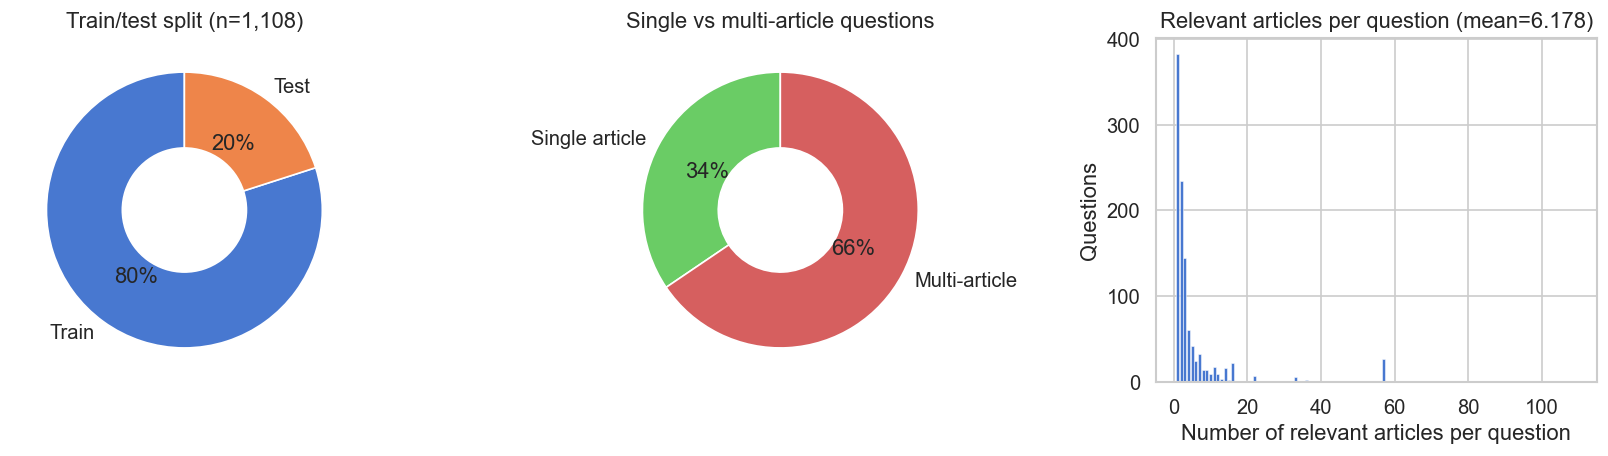

In [9]:
qs = STATS["questions"]
rel_dist = {int(k): v for k, v in qs["relevant_articles_distribution"].items()}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Train / test split
axes[0].pie([qs["train"], qs["test"]], labels=["Train", "Test"],
            autopct="%1.0f%%", colors=["#4878d0", "#ee854a"],
            wedgeprops=dict(width=0.55), startangle=90)
axes[0].set_title(f"Train/test split (n={qs['total']:,})")

# Single vs multi article
n_single = qs["total"] - qs["multi_article"]
axes[1].pie([n_single, qs["multi_article"]],
            labels=["Single article", "Multi-article"],
            autopct="%1.0f%%", colors=["#6acc65", "#d65f5f"],
            wedgeprops=dict(width=0.55), startangle=90)
axes[1].set_title("Single vs multi-article questions")

# Distribution of number of relevant articles
x_vals = sorted(rel_dist.keys())
y_vals = [rel_dist[k] for k in x_vals]
axes[2].bar(x_vals, y_vals, color="#4878d0", edgecolor="white", linewidth=0.3)
axes[2].set_xlabel("Number of relevant articles per question")
axes[2].set_ylabel("Questions")
axes[2].set_title(f"Relevant articles per question (mean={qs['avg_relevant_articles']})")

plt.tight_layout()
plt.show()

### 1.9 Jaccard Lexical Overlap — Query vs Relevant Article

,Value
Statistic,
n pairs,6845.0000
mean,0.0520
std,0.0355
p10,0.0167
p25,0.0285
p50,0.0450
p75,0.0678
p90,0.0954
p95,0.1200


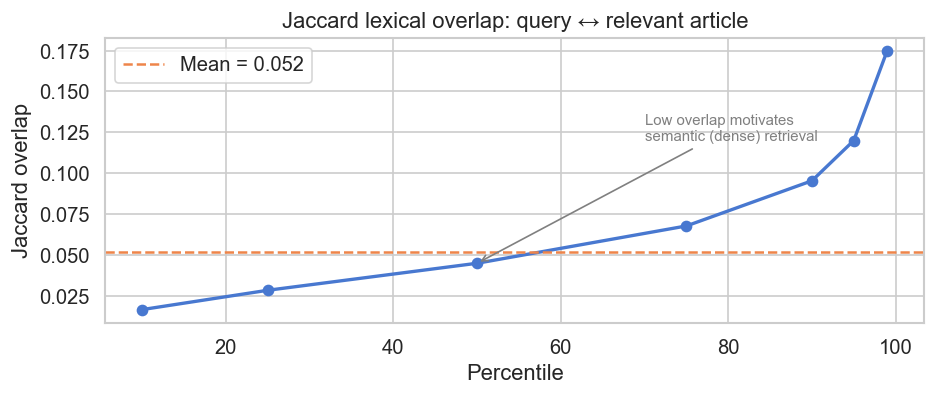

In [10]:
jq = STATS["jaccard_overlap"]

pct_keys = ["p10", "p25", "p50", "p75", "p90", "p95", "p99"]
jac_df = pd.DataFrame([
    ("n pairs",   jq["n_pairs"]),
    ("mean",      jq["mean"]),
    ("std",       jq["std"]),
    *[(k, jq[k]) for k in pct_keys if k in jq],
], columns=["Statistic", "Value"])
display(jac_df.set_index("Statistic"))

fig, ax = plt.subplots(figsize=(8, 3.5))
pct_x = [int(k[1:]) for k in pct_keys if k in jq]
pct_y = [jq[k]      for k in pct_keys if k in jq]
ax.plot(pct_x, pct_y, marker="o", color="#4878d0", linewidth=2)
ax.axhline(jq["mean"], linestyle="--", color="#ee854a", label=f"Mean = {jq['mean']}")
ax.set_xlabel("Percentile")
ax.set_ylabel("Jaccard overlap")
ax.set_title("Jaccard lexical overlap: query ↔ relevant article")
ax.legend()
ax.annotate("Low overlap motivates\nsemantic (dense) retrieval",
            xy=(50, jq.get("p50", 0.045)), xytext=(70, 0.12),
            arrowprops=dict(arrowstyle="->", color="grey"),
            fontsize=9, color="grey")
plt.tight_layout()
plt.show()

### 1.10 Temporal Metadata & Verification Status

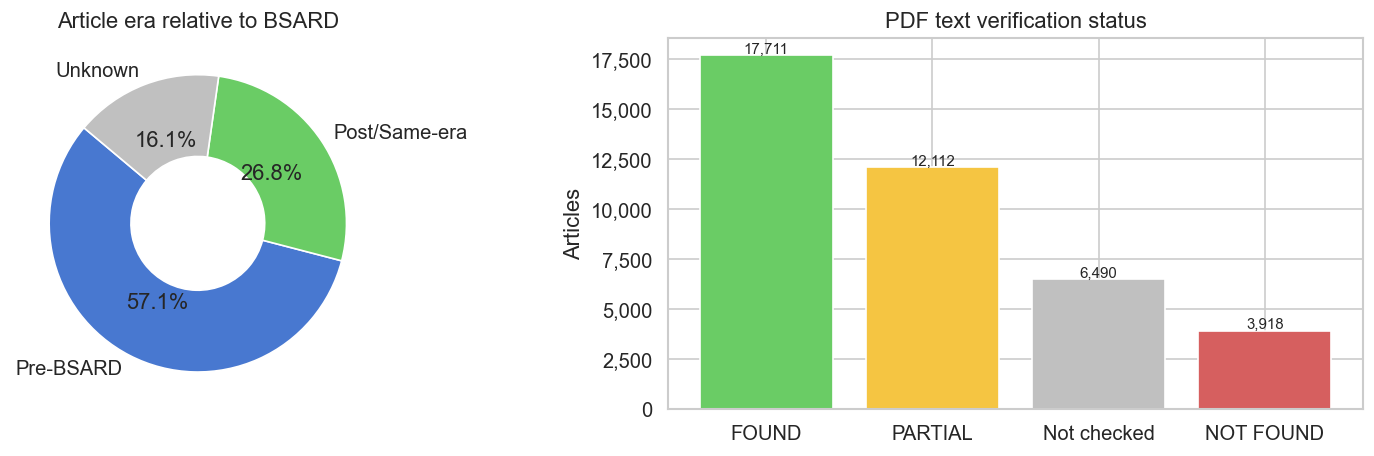

In [11]:
tm = STATS["temporal"]
vs = STATS["verification_status"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Temporal
t_labels = ["Pre-BSARD", "Post/Same-era", "Unknown"]
t_values = [tm["pre_bsard"], tm["post_bsard_or_same"], tm["pre_bsard_unknown"]]
axes[0].pie(t_values, labels=t_labels, autopct="%1.1f%%",
            colors=["#4878d0", "#6acc65", "#c0c0c0"],
            wedgeprops=dict(width=0.55), startangle=140)
axes[0].set_title("Article era relative to BSARD")

# Verification status
vs_clean = {k if k != "NULL" else "Not checked": v for k, v in vs.items()}
vs_df = pd.Series(vs_clean).sort_values(ascending=False)
axes[1].bar(vs_df.index, vs_df.values,
            color=["#6acc65", "#f5c542", "#c0c0c0", "#d65f5f"][:len(vs_df)])
axes[1].set_ylabel("Articles")
axes[1].set_title("PDF text verification status")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for i, (v, k) in enumerate(zip(vs_df.values, vs_df.index)):
    axes[1].text(i, v + 100, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### 1.11 Questions — Sample Exploration

In [12]:
questions_df = pd.read_sql("""
    SELECT question_id, split, question_text, n_relevant_articles,
           relevant_bsard_ids, relevant_article_ids
    FROM questions
    ORDER BY n_relevant_articles DESC
""", conn)

pd.set_option("display.max_colwidth", 120)
display(questions_df.head(10))

,question_id,split,question_text,n_relevant_articles,relevant_bsard_ids,relevant_article_ids
0,53,train,Qu'est-ce qu'un crédit hypothécaire ?,109,"[2589, 2590, 2591, 2592, 2593, 2594, 2595, 2596, 2597, 2598, 2599, 2600, 2601, 2602, 2603, 2604, 2605, 2606, 2607, 2...","[2331, 2332, 2737, 2738, 2739, 2740, 2333, 2742, 2743, 2744, 2745, 2746, 2747, 2748, 2334, 2750, 2751, 2752, 2335, 2..."
1,51,train,"Si je ne rembourse pas mon crédit hypothécaire, peut-on faire vendre ma maison ?",93,"[5861, 5862, 5863, 5864, 5865, 5866, 5867, 5868, 5869, 5870, 5871, 5872, 5873, 5874, 5875, 5876, 5877, 5878, 5879, 5...","[9263, 9538, 9539, 9540, 9541, 9542, 9543, 9544, 9545, 9546, 9547, 9548, 9549, 9550, 9551, 9552, 9553, 9554, 9555, 9..."
2,52,train,Que se passe-t-il si je ne paie pas mon crédit hypothécaire ?,82,"[5861, 5862, 5863, 5864, 5865, 5866, 5867, 5868, 5869, 5870, 5871, 5872, 5873, 5874, 5875, 5876, 5877, 5878, 5879, 5...","[9263, 9538, 9539, 9540, 9541, 9542, 9543, 9544, 9545, 9546, 9547, 9548, 9549, 9550, 9551, 9552, 9553, 9554, 9555, 9..."
3,1,train,Les régimes de protection des personnes fragilisées ?,74,"[1355, 1356, 1357, 1358, 1359, 1360, 1361, 1362, 1363, 1364, 1365, 1366, 1367, 1368, 1369, 1370, 1371, 1372, 1373, 1...","[120, 119, 778, 121, 780, 781, 782, 122, 123, 785, 786, 787, 788, 124, 791, 792, 793, 125, 126, 127, 797, 798, 799, ..."
4,1073,train,Les régimes de protection des personnes fragilisées ?,74,"[1355, 1356, 1357, 1358, 1359, 1360, 1361, 1362, 1363, 1364, 1365, 1366, 1367, 1368, 1369, 1370, 1371, 1372, 1373, 1...","[120, 119, 778, 121, 780, 781, 782, 122, 123, 785, 786, 787, 788, 124, 791, 792, 793, 125, 126, 127, 797, 798, 799, ..."
5,660,train,Quel est le rôle du parquet en matière pénale ?,70,"[13211, 13212, 13213, 13214, 13215, 13216, 13217, 13218, 13219, 13220, 13221, 13222, 13223, 13224, 13225, 13226, 132...","[3058, 3123, 35786, 3125, 3126, 3127, 3128, 3129, 3059, 3131, 3132, 3133, 3134, 3135, 3136, 3137, 3061, 3140, 3141, ..."
6,67,train,Puis-je invoquer la prescription pour ne pas payer ma dette ?,66,"[2784, 2785, 2786, 2787, 2788, 2789, 2790, 2791, 2792, 2793, 2794, 2795, 2796, 2797, 2798, 2799, 2800, 2801, 2802, 2...","[2889, 2983, 2984, 2985, 2986, 2987, 2988, 2989, 2990, 2890, 2992, 2993, 2994, 2995, 2996, 2997, 2998, 2891, 3000, 3..."
7,782,train,Je loue un garage. Quelles règles s'appliquent à mon bail en Wallonie ?,61,"[2475, 2476, 2477, 2478, 2479, 2480, 2481, 2482, 2483, 2484, 2485, 2486, 2487, 2488, 2489, 2490, 2491, 2492, 2493, 2...","[2198, 2200, 34415, 2204, 2206, 34416, 2528, 34417, 2213, 2215, 2217, 34418, 2220, 2222, 2224, 2226, 2228, 2230, 223..."
8,109,train,Ai-je droit à l'aide juridique (ex pro deo) si je suis surendetté ?,57,"[4478, 4479, 4480, 4481, 4482, 4483, 4484, 4485, 4486, 4487, 4488, 4489, 4490, 4491, 4492, 4493, 4494, 4495, 4496, 4...","[6788, 6789, 6790, 6791, 6792, 6793, 6795, 6796, 6797, 6798, 6799, 7654, 7655, 7656, 7657, 7658, 6800, 7660, 7661, 7..."
9,616,test,Puis-je avoir une aide pour payer les frais de justice (assistance judiciaire) ?,57,"[4478, 4479, 4480, 4481, 4482, 4483, 4484, 4485, 4486, 4487, 4488, 4489, 4490, 4491, 4492, 4493, 4494, 4495, 4496, 4...","[6788, 6789, 6790, 6791, 6792, 6793, 6795, 6796, 6797, 6798, 6799, 7654, 7655, 7656, 7657, 7658, 6800, 7660, 7661, 7..."


---
## Part 2 — Article Deep-Dive

Use the cells below to inspect any article in the corpus.  
**Three lookup modes** (set exactly one; leave the others as `None`):
- `BSARD_ID` — the integer BSARD benchmark ID
- `ARTICLE_NUMBER` + `LAW_CODE` — e.g. `"2"` and `"Code des Sociétés et des Associations"`
- `ARTICLE_ID` — the internal integer primary key (1–40231)

In [13]:
# ── Set your lookup here ──────────────────────────────────────────────────────
BSARD_ID       = 1          # integer BSARD id, or None
ARTICLE_NUMBER = None       # e.g. "2", or None
LAW_CODE       = None       # e.g. "Code des Sociétés et des Associations", or None
ARTICLE_ID     = None       # internal integer primary key, or None
# ─────────────────────────────────────────────────────────────────────────────

def _fetch_article(bsard_id=None, article_number=None, law_code=None, article_id=None):
    if bsard_id is not None:
        rows = conn.execute(
            "SELECT * FROM articles WHERE bsard_id = ? ORDER BY article_id",
            (bsard_id,)
        ).fetchall()
    elif article_id is not None:
        rows = conn.execute(
            "SELECT * FROM articles WHERE article_id = ?", (article_id,)
        ).fetchall()
    elif article_number is not None and law_code is not None:
        rows = conn.execute(
            "SELECT * FROM articles WHERE article_number = ? AND law_code = ? ORDER BY article_id",
            (article_number, law_code)
        ).fetchall()
    else:
        raise ValueError("Provide BSARD_ID, ARTICLE_ID, or both ARTICLE_NUMBER + LAW_CODE")

    if not rows:
        print("No article found.")
        return None
    if len(rows) > 1:
        print(f"  {len(rows)} records share this identifier — showing all.")
    return rows

rows = _fetch_article(BSARD_ID, ARTICLE_NUMBER, LAW_CODE, ARTICLE_ID)
if rows:
    print(f"Found {len(rows)} record(s).")

Found 1 record(s).


#### 2.1 Core Metadata

In [14]:
def _display_metadata(row):
    keys = [
        "article_id", "bsard_id", "is_bsard_article",
        "law_code", "law_type", "article_number", "numac",
        "article_text_source",
        "law_title_text", "chapter_title", "section_title",
        "subsection_title", "hierarchy_depth",
        "pdf_filename", "pdf_page_start", "pdf_page_end",
        "justel_html_url",
        "amendment_date", "article_status", "is_pre_bsard",
        "html_text_found", "pdf_text_found",
        "pdf_match_category", "verification_status",
        "token_count", "char_count",
        "has_cross_references",
        "n_outgoing_refs", "n_cited_by",
    ]
    df = pd.DataFrame(
        [(k, row[k]) for k in keys if row[k] is not None],
        columns=["Field", "Value"]
    )
    display(df.set_index("Field").style.set_properties(**{"text-align": "left"}))

if rows:
    for i, row in enumerate(rows):
        if len(rows) > 1:
            print(f"\n── Record {i+1} of {len(rows)} (article_id={row['article_id']}) ──")
        _display_metadata(row)

,Value
Field,
article_id,22849
bsard_id,1
is_bsard_article,1
law_code,"Code Bruxellois de l'Air, du Climat et de la Maîtrise de l'Energie"
law_type,regional
article_number,1.1.1-1.1.2
numac,2013031357
article_text_source,bsard_dataset
hierarchy_depth,0


#### 2.2 Article Text

In [15]:
if rows:
    for i, row in enumerate(rows):
        if len(rows) > 1:
            print(f"\n── Record {i+1} (article_id={row['article_id']}) ──")
        text = row["article_text"]
        if text:
            print(f"[{row['token_count']} tokens | {row['char_count']} chars]\n")
            print(text)
        else:
            print("(no article text)")

[19 tokens | 74 chars]

Le présent Code règle une matière visée à l'article 39 de la Constitution.


#### 2.3 Hierarchy Path

In [16]:
# hierarchy_path is a flat JSON list of heading strings in document order
_LEVEL_PREFIXES = [
    ("SOUS-SECTION", 5), ("SECTION",   4), ("CHAPITRE", 3),
    ("TITRE",        2), ("LIVRE",     1), ("PARTIE",   1),
    ("BOEK",         1), ("TITEL",     2), ("HOOFDSTUK",3),
    ("AFDELING",     4), ("Art",       6),
]

def _indent_level(s):
    su = s.strip().upper()
    for prefix, depth in _LEVEL_PREFIXES:
        if su.startswith(prefix.upper()):
            return depth
    return 0

if rows:
    for i, row in enumerate(rows):
        if len(rows) > 1:
            print(f"\n── Record {i+1} (article_id={row['article_id']}) ──")
        hp = row["hierarchy_path"]
        if hp:
            for entry in json.loads(hp):
                print("  " * _indent_level(entry) + entry)
        else:
            print("(no hierarchy path)")

            Art. 1.1.1-1.1.2


#### 2.4 Cross-References (outgoing)

In [17]:
def _show_outgoing(article_id):
    edges = conn.execute("""
        SELECT cg.citation_text, cg.resolved,
               a.article_id AS target_id, a.law_code, a.article_number,
               substr(a.article_text, 1, 100) AS preview
        FROM citation_graph cg
        LEFT JOIN articles a ON a.article_id = cg.target_id
        WHERE cg.source_id = ?
        ORDER BY cg.edge_id
    """, (article_id,)).fetchall()

    if not edges:
        print("  No outgoing citations.")
        return

    df = pd.DataFrame([
        dict(e) for e in edges
    ])
    display(df)

if rows:
    for i, row in enumerate(rows):
        aid = row["article_id"]
        print(f"\nOutgoing citations from article_id={aid} (n={row['n_outgoing_refs']}):")
        _show_outgoing(aid)


Outgoing citations from article_id=22849 (n=1):
  No outgoing citations.


#### 2.5 Cited By (incoming)

In [18]:
def _show_incoming(article_id):
    edges = conn.execute("""
        SELECT cg.citation_text,
               a.article_id AS source_id, a.law_code, a.article_number,
               substr(a.article_text, 1, 100) AS preview
        FROM citation_graph cg
        LEFT JOIN articles a ON a.article_id = cg.source_id
        WHERE cg.target_id = ?
        ORDER BY a.law_code, a.article_number
    """, (article_id,)).fetchall()

    if not edges:
        print("  Not cited by any article.")
        return

    df = pd.DataFrame([dict(e) for e in edges])
    display(df)

if rows:
    for i, row in enumerate(rows):
        aid = row["article_id"]
        print(f"\nArticles citing article_id={aid} (n={row['n_cited_by']}):")
        _show_incoming(aid)


Articles citing article_id=22849 (n=0):
  Not cited by any article.


#### 2.6 Raw Cross-Reference Strings

In [19]:
# cross_references_raw  — list of citation text strings found in the article
# cross_reference_ids   — list of resolved article_id integers (may differ in length)
if rows:
    for i, row in enumerate(rows):
        if len(rows) > 1:
            print(f"\n── Record {i+1} (article_id={row['article_id']}) ──")
        raw      = row["cross_references_raw"]
        resolved = row["cross_reference_ids"]
        if raw:
            raw_list = json.loads(raw)
            res_list = json.loads(resolved) if resolved else []
            print(f"Raw citation strings ({len(raw_list)}):")
            display(pd.DataFrame(raw_list, columns=["citation_text"]))
            if res_list:
                print(f"\nResolved article_ids ({len(res_list)}):")
                res_arts = pd.read_sql(
                    f"SELECT article_id, law_code, article_number FROM articles "
                    f"WHERE article_id IN ({','.join('?'*len(res_list))})",
                    conn, params=res_list
                )
                display(res_arts)
        else:
            print("  (no raw cross-references)")

Raw citation strings (1):


,citation_text
0,article 39


#### 2.7 Linked Questions

In [20]:
def _linked_questions(article_id):
    all_qs = conn.execute(
        "SELECT question_id, split, question_text, relevant_article_ids, n_relevant_articles FROM questions"
    ).fetchall()
    matched = [
        dict(q) for q in all_qs
        if article_id in json.loads(q["relevant_article_ids"] or "[]")
    ]
    if not matched:
        print("  No questions reference this article.")
        return
    display(pd.DataFrame(matched)[["question_id", "split", "n_relevant_articles", "question_text"]])

if rows:
    for i, row in enumerate(rows):
        aid = row["article_id"]
        print(f"\nQuestions referencing article_id={aid}:")
        _linked_questions(aid)


Questions referencing article_id=22849:
  No questions reference this article.


---
## Part 3 — Search Utilities

### 3.1 Full-text search (FTS5)

In [21]:
FTS_QUERY = "contrat de travail"   # ← change this
FTS_LIMIT = 10

fts_rows = conn.execute("""
    SELECT a.article_id, a.bsard_id, a.law_code, a.article_number,
           a.token_count,
           snippet(articles_fts, 0, '>>>', '<<<', '...', 15) AS snippet
    FROM articles_fts
    JOIN articles a ON a.article_id = articles_fts.rowid
    WHERE articles_fts MATCH ?
    ORDER BY rank
    LIMIT ?
""", (FTS_QUERY, FTS_LIMIT)).fetchall()

print(f"Top {FTS_LIMIT} results for: '{FTS_QUERY}'\n")
for r in fts_rows:
    print(f"  [{r['article_id']}] bsard={r['bsard_id']}  {r['law_code']}  Art.{r['article_number']}  "
          f"({r['token_count']} tok)")
    print(f"    {r['snippet']}\n")

Top 10 results for: 'contrat de travail'

  [23854] bsard=8530  Code Réglementaire Wallon de l'Action sociale et de la Santé  Art.1052-1061  (126 tok)
    ...>>>contrat<<< d'entreprise entre l'entreprise >>>de<<< >>>travail<<< adapté et l'entreprise extérieure.Par >>>contrat<<<...

  [25970] bsard=8530  Code Réglementaire Wallon de l'Action sociale et de la Santé  Art.1052  (126 tok)
    ...>>>contrat<<< d'entreprise entre l'entreprise >>>de<<< >>>travail<<< adapté et l'entreprise extérieure.Par >>>contrat<<<...

  [40190] bsard=22202  Code du Bien-être au Travail  Art.X.3  (318 tok)
    ...>>>contrat<<< >>>de<<< >>>travail<<< ou qui, autrement qu'en vertu d'un >>>contrat<<< >>>de<<< >>>travail<<<, exécute...

  [17450] bsard=7076  Code Pénal Social  Art.186  (968 tok)
    ...>>>contrat<<< >>>de<<< >>>travail<<< pour l'exécution >>>de<<< >>>travail<<< temporaireEst puni d'une sanction >>>de<<< niveau...

  [17795] bsard=7076  Code Pénal Social  Art.186  (968 tok)
    ...>>>contrat<<< >

### 3.2 Filter articles by law code

In [22]:
# List all available law codes first
law_codes = pd.read_sql(
    "SELECT law_code, COUNT(*) AS n FROM articles GROUP BY law_code ORDER BY n DESC",
    conn
)
display(law_codes)

,law_code,n
0,Code de la Démocratie Locale et de la Décentralisation,4464
1,Code Réglementaire Wallon de l'Action sociale et de la Santé,4355
2,Code Judiciaire,3432
3,Code de Droit Economique,3188
4,Code Civil,3163
5,Code du Bien-être au Travail,3064
6,Code Wallon de l'Action sociale et de la Santé,1811
7,Code de la Navigation,1613
8,Code Wallon du Développement Territorial,1612
9,Code des Sociétés et des Associations,1194


In [23]:
FILTER_LAW_CODE = "Code des Sociétés et des Associations"  # ← change this

filtered = pd.read_sql("""
    SELECT article_id, bsard_id, article_number, article_number,
           chapter_title, section_title,
           token_count, n_outgoing_refs, n_cited_by,
           verification_status,
           substr(article_text, 1, 150) AS preview
    FROM articles
    WHERE law_code = ?
    ORDER BY article_id
""", conn, params=(FILTER_LAW_CODE,))

print(f"{len(filtered):,} articles in '{FILTER_LAW_CODE}'")
display(filtered.head(20))

1,194 articles in 'Code des Sociétés et des Associations'


,article_id,bsard_id,article_number,article_number,chapter_title,section_title,token_count,n_outgoing_refs,n_cited_by,verification_status,preview
0,37788,19754,1,1,None,None,82,0,48,NOT FOUND,"Une société est constituée par un acte juridique par lequel une ou plusieurs personnes, dénommées associés, font un ..."
1,37789,19755,1,1,None,None,123,0,0,NOT FOUND,"Une association est constituée par une convention entre deux ou plusieurs personnes, dénommées membres. Elle poursui..."
2,37790,19756,1,1,None,None,148,0,0,NOT FOUND,"Une fondation est une personne morale dépourvue de membres, constituée par un acte juridiquepar une ou plusieurs per..."
3,37791,19757,1,1,None,None,146,2,0,NOT FOUND,Aux fins des articles 1:2 et 1:3 est considérée comme distribution indirecte d'un avantage patrimonial toute opérati...
4,37792,19758,1,1,None,None,180,0,0,NOT FOUND,§ 1er. La société simple est une société qui est dépourvue de personnalité juridique.§ 2. Le présent code reconnaît ...
5,37793,19759,1,1,None,None,90,0,0,NOT FOUND,§ 1er. L'association de fait est une association sans personnalité juridique régie par la convention des parties.§ 2...
6,37794,19760,1,1,None,None,52,0,0,NOT FOUND,"Le présent code reconnaît en tant que fondation dotée de la personnalité juridique:- la fondation privée, en abrégé ..."
7,37795,19761,1,1,None,None,239,0,0,NOT FOUND,§ 1er. L'apport est l'acte par lequel une personne met quelque chose à disposition d'une société à constituer ou d'u...
8,37796,19762,1,1,None,None,221,0,0,NOT FOUND,§ 1er. Chaque associé est débiteur envers la société de ce qu'il a promis d'apporter.§ 2. Sauf convention contraire:...
9,37797,19763,1,1,None,None,207,1,0,NOT FOUND,"§ 1er. Sauf convention contraire, la chose certaine faisant l'objet d'un apport en propriété est aux risques de la s..."


### 3.3 Question browser

In [24]:
QUESTION_ID = 1   # ← change this (1 to 1108)

q = conn.execute(
    "SELECT * FROM questions WHERE question_id = ?", (QUESTION_ID,)
).fetchone()

if q:
    print(f"Question #{q['question_id']} [{q['split']}]")
    print(f"\n{q['question_text']}\n")
    bsard_ids  = json.loads(q["relevant_bsard_ids"])
    art_ids    = json.loads(q["relevant_article_ids"])
    print(f"Relevant BSARD IDs   : {bsard_ids}")
    print(f"Relevant article IDs : {art_ids}")
    print(f"N relevant articles  : {q['n_relevant_articles']}")

    print("\n── Relevant articles ──")
    for aid in art_ids:
        a = conn.execute(
            "SELECT article_id, bsard_id, law_code, article_number, token_count, "
            "substr(article_text, 1, 200) AS preview FROM articles WHERE article_id = ?",
            (aid,)
        ).fetchone()
        if a:
            print(f"\n  [{a['article_id']}] bsard={a['bsard_id']} | {a['law_code']} Art.{a['article_number']} ({a['token_count']} tok)")
            print(f"  {a['preview']}...")
else:
    print("Question not found.")

Question #1 [train]

Les régimes de protection des personnes fragilisées ?

Relevant BSARD IDs   : [1355, 1356, 1357, 1358, 1359, 1360, 1361, 1362, 1363, 1364, 1365, 1366, 1367, 1368, 1369, 1370, 1371, 1372, 1373, 1374, 1375, 1376, 1377, 1378, 1379, 1380, 1381, 1382, 1383, 1384, 1385, 1386, 1387, 1388, 1389, 1390, 1391, 1392, 1393, 1394, 1395, 1396, 1397, 1398, 1399, 1400, 1401, 1402, 1403, 1404, 1405, 1406, 1407, 1408, 1409, 1410, 1411, 1412, 1413, 1414, 1415, 1416, 1417, 1418, 1419, 1420, 1421, 1422, 1423, 1424, 1425, 1426, 1427, 1428]
Relevant article IDs : [120, 119, 778, 121, 780, 781, 782, 122, 123, 785, 786, 787, 788, 124, 791, 792, 793, 125, 126, 127, 797, 798, 799, 800, 801, 802, 803, 128, 805, 806, 807, 808, 809, 810, 811, 812, 129, 814, 815, 816, 817, 130, 819, 820, 821, 822, 823, 824, 825, 826, 827, 828, 829, 830, 831, 832, 833, 834, 835, 836, 837, 838, 839, 840, 131, 842, 843, 844, 845, 132, 847, 848, 849, 133]
N relevant articles  : 74

── Relevant articles ──

  [120] bs

In [25]:
# Close connection when done
# conn.close()